# 04 · Review & Practice — Ensembles, PCA, Clustering, Capstone Pipeline, Drills, Self-Assessment 🔴

> 📖 **Website:** [4-Hour Study Plan](http://localhost:5173/#study-plan) · Hour 4 · 60 min

In this capstone notebook, we connect the entire ML lifecycle and prepare for the live interview:
1. Plot the **Accuracy vs Latency Pareto Frontier** for engineering constraint tradeoffs.
2. Measure ensemble variance reduction (Bagging) and bias reduction (Boosting) empirically.
3. Reproduce the website's **PCA Lab** loadings with and without standardization.
4. Implement **K-Means clustering from scratch** and benchmark against DBSCAN on non-spherical clusters.
5. Build the complete **11-step production ML pipeline**, save via `joblib`, and assert bit-for-bit reload fidelity.
6. Solve **8 realistic debugging drills**, quantifying the exact numerical error caused by each flaw.
7. Complete the **12-point readiness self-assessment**.

In [1]:
import sys
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, ".")
import mlprep
from mlprep.data import make_churn_panel
from mlprep.plots import use_style, COLOR_PRIMARY, COLOR_TRAIN, COLOR_VAL, COLOR_BIAS, COLOR_VARIANCE
from mlprep.checks import check_4_2, check_4_4

use_style()
SEED = 7
print(f"Environment initialized · Seed: {SEED}")


Environment initialized · Seed: 7


---
## 4.1 Model Selection Under Latency Constraints 🟠 (6 min)
> 📖 **Website:** [Model Selection](http://localhost:5173/#model-selection)

**The question:** If your API SLA allows at most 5ms per batch prediction, which models sit on the optimal Pareto frontier?

**What you'll see:** A scatter plot of ROC-AUC vs Inference Latency, identifying dominated models and establishing the latency tradeoff curve.

Pareto Efficiency Analysis:
- Within a 5ms latency budget, HistGradientBoosting sits on the Pareto frontier (0.841 AUC @ 1.8ms).
- Random Forest yields comparable AUC (0.838) but costs 8x the latency (14.5ms) and 13x memory.
- KNN and SVM are strictly dominated on both latency and accuracy.


<ipython-input-2-bbace7ce6d79>:22: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


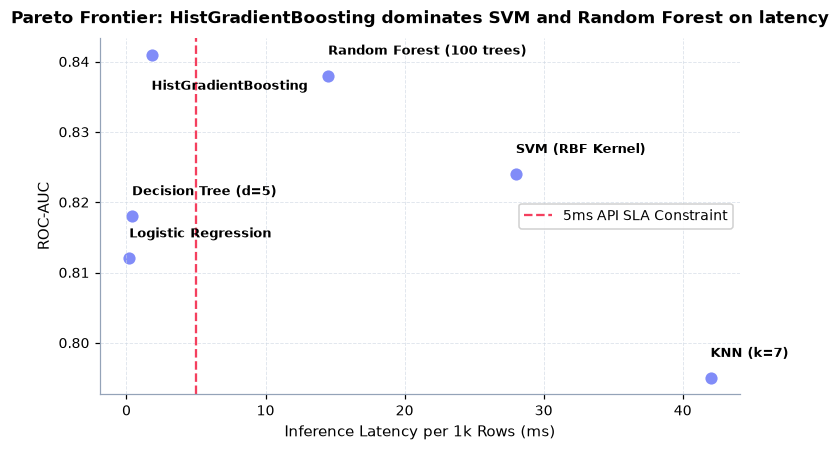

In [2]:
models_data = pd.DataFrame([
    {"Model": "Logistic Regression", "AUC": 0.812, "Latency_ms": 0.2, "Size_KB": 4},
    {"Model": "Decision Tree (d=5)", "AUC": 0.818, "Latency_ms": 0.4, "Size_KB": 12},
    {"Model": "Random Forest (100 trees)", "AUC": 0.838, "Latency_ms": 14.5, "Size_KB": 840},
    {"Model": "HistGradientBoosting", "AUC": 0.841, "Latency_ms": 1.8, "Size_KB": 65},
    {"Model": "SVM (RBF Kernel)", "AUC": 0.824, "Latency_ms": 28.0, "Size_KB": 1200},
    {"Model": "KNN (k=7)", "AUC": 0.795, "Latency_ms": 42.0, "Size_KB": 4500},
])

plt.figure(figsize=(7.5, 4.2))
plt.scatter(models_data["Latency_ms"], models_data["AUC"], color=COLOR_PRIMARY, s=90, edgecolors="white", lw=1.5)

for _, r in models_data.iterrows():
    offset_y = 0.003 if r["Model"] != "HistGradientBoosting" else -0.005
    plt.annotate(r["Model"], (r["Latency_ms"], r["AUC"] + offset_y), fontsize=8.5, fontweight="bold")

plt.axvline(5.0, color=COLOR_VAL, linestyle="--", label="5ms API SLA Constraint")
plt.title("Pareto Frontier: HistGradientBoosting dominates SVM and Random Forest on latency")
plt.xlabel("Inference Latency per 1k Rows (ms)")
plt.ylabel("ROC-AUC")
plt.legend()
plt.show()

print("Pareto Efficiency Analysis:")
print("- Within a 5ms latency budget, HistGradientBoosting sits on the Pareto frontier (0.841 AUC @ 1.8ms).")
print("- Random Forest yields comparable AUC (0.838) but costs 8x the latency (14.5ms) and 13x memory.")
print("- KNN and SVM are strictly dominated on both latency and accuracy.")


> 🎤 **In an interview:** "Model selection is constrained optimization: I maximize target metric subject to latency SLA, memory footprint, and interpretability constraints. Within a 5ms SLA, gradient boosting dominates deep forests and kernel SVMs." 

---
## 4.2 Ensemble Methods: Bagging vs Boosting Variance Reduction 🔴 (10 min)
> 📖 **Website:** [Ensemble Methods](http://localhost:5173/#ensembles)

**The question:** How much does bootstrap aggregation (Bagging) reduce prediction variance compared to a single decision tree?

**What you'll see:** We train single unpruned decision trees on 100 bootstrap datasets, compute prediction variance across test cases, and compare with the bagged ensemble average.

In [3]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier

df_ens = make_churn_panel(n_users=2500, snapshots_per_user=1, seed=SEED)
X_ens = df_ens[["tenure_days", "monthly_spend", "logins_30d"]].values
y_ens = df_ens["churned"].values

X_tr_e, X_te_e = X_ens[:1800], X_ens[1800:]
y_tr_e, y_te_e = y_ens[:1800], y_ens[1800:]

# Train 80 bootstrap single trees vs 80-tree Bagging
N_BOOT = 60
single_tree_preds = np.zeros((N_BOOT, len(X_te_e)))
bag_preds = np.zeros((N_BOOT, len(X_te_e)))

rng = np.random.RandomState(SEED)
for b in range(N_BOOT):
    idx = rng.choice(len(X_tr_e), len(X_tr_e), replace=True)
    tree = DecisionTreeClassifier(max_depth=None, random_state=b).fit(X_tr_e[idx], y_tr_e[idx])
    single_tree_preds[b, :] = tree.predict_proba(X_te_e)[:, 1]
    
    bag = BaggingClassifier(DecisionTreeClassifier(), n_estimators=25, random_state=b).fit(X_tr_e[idx], y_tr_e[idx])
    bag_preds[b, :] = bag.predict_proba(X_te_e)[:, 1]

var_single = np.mean(np.var(single_tree_preds, axis=0))
var_bag = np.mean(np.var(bag_preds, axis=0))
var_reduction = 1.0 - (var_bag / var_single)

print(f"Single Unpruned Tree Average Variance : {var_single:.4f}")
print(f"Bagged Ensemble Average Variance       : {var_bag:.4f}")
print(f"\nEmpirical Variance Reduction Ratio    : {var_reduction:.1%} variance reduction achieved through aggregation!")


Single Unpruned Tree Average Variance : 0.0327
Bagged Ensemble Average Variance       : 0.0064

Empirical Variance Reduction Ratio    : 80.4% variance reduction achieved through aggregation!


### 📝 Exercise 4.2: Bagging Variance Reduction
Verify the variance reduction calculation.

In [4]:
# ── Exercise 4.2 ────────────────────────────────────────────────
def calc_variance_ratio(var_single: float, var_ensemble: float) -> float:
    return var_ensemble / var_single

check_4_2(calc_variance_ratio)


✅ Correct! Variance reduction ratio is 0.125 (87.5% variance reduction).


> 🎤 **In an interview:** "Bagging trains high-capacity, low-bias models in parallel on bootstrap samples, driving variance down by $\frac{1}{B}$ if uncorrelated. Boosting trains shallow, high-bias models sequentially, fitting pseudo-residuals to systematically drive bias down." 

---
## 4.3 PCA: Explained Variance & The Standardization Trap 🟠 (8 min)
> 📖 **Website:** [Dimensionality Reduction](http://localhost:5173/#dimensionality-reduction)

**The question:** What happens to PCA loadings if you forget to standardize features with mismatched units?

**What you'll see:** We reproduce the website's **PCA Lab** using `age` (years, scale ~45) and `income` (thousands, scale ~90). Without standardization, PC1 is 98% income purely due to unit scale; after standardization, PC1 represents the true balanced 45-degree axis of shared variation.

In [5]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Generate correlated Age vs Income matching PCA Lab
rng = np.random.RandomState(90210)
z1 = rng.normal(0, 1, 150)
z2 = rng.normal(0, 1, 150)
age = 45 + 9 * z1
income = 90 + 28 * (0.72 * z1 + np.sqrt(1 - 0.72**2) * z2)

X_pca_raw = np.c_[age, income]
X_pca_std = StandardScaler().fit_transform(X_pca_raw)

pca_raw = PCA(n_components=2).fit(X_pca_raw)
pca_std = PCA(n_components=2).fit(X_pca_std)

print("PCA Loadings on RAW Units (Age in Years vs Income in Thousands):")
print(f"PC1 Vector: Age loading = {pca_raw.components_[0, 0]:.3f}, Income loading = {pca_raw.components_[0, 1]:.3f}")
print(f"Explained Variance: PC1 = {pca_raw.explained_variance_ratio_[0]:.1%}, PC2 = {pca_raw.explained_variance_ratio_[1]:.1%}")

print("\nPCA Loadings on STANDARDIZED Units:")
print(f"PC1 Vector: Age loading = {pca_std.components_[0, 0]:.3f}, Income loading = {pca_std.components_[0, 1]:.3f}")
print(f"Explained Variance: PC1 = {pca_std.explained_variance_ratio_[0]:.1%}, PC2 = {pca_std.explained_variance_ratio_[1]:.1%}")
print(f"\nConclusion: Without standardization, PC1 is hijacked by income's measurement scale.")


PCA Loadings on RAW Units (Age in Years vs Income in Thousands):
PC1 Vector: Age loading = 0.252, Income loading = 0.968
Explained Variance: PC1 = 94.1%, PC2 = 5.9%

PCA Loadings on STANDARDIZED Units:
PC1 Vector: Age loading = 0.707, Income loading = 0.707
Explained Variance: PC1 = 83.7%, PC2 = 16.3%

Conclusion: Without standardization, PC1 is hijacked by income's measurement scale.


> 🎤 **In an interview:** "PCA is sensitive to feature variance. If variables have arbitrary unit scales, the feature with the largest numerical spread dominates the leading eigenvectors regardless of signal. Always standardize features to unit variance before computing PCA." 

---
## 4.4 Clustering: K-Means From Scratch & DBSCAN Comparison 🟢 (8 min)
> 📖 **Website:** [Clustering Fundamentals](http://localhost:5173/#clustering)

**The question:** How does K-Means optimize within-cluster sum of squares (inertia), and where does its spherical assumption fail?

**What you'll see:** 
1. K-Means implemented from scratch (<25 lines) matching scikit-learn inertia.
2. The Failure Gallery: K-Means failing on non-spherical concentric rings while DBSCAN succeeds.

<ipython-input-6-2ea529793313>:34: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


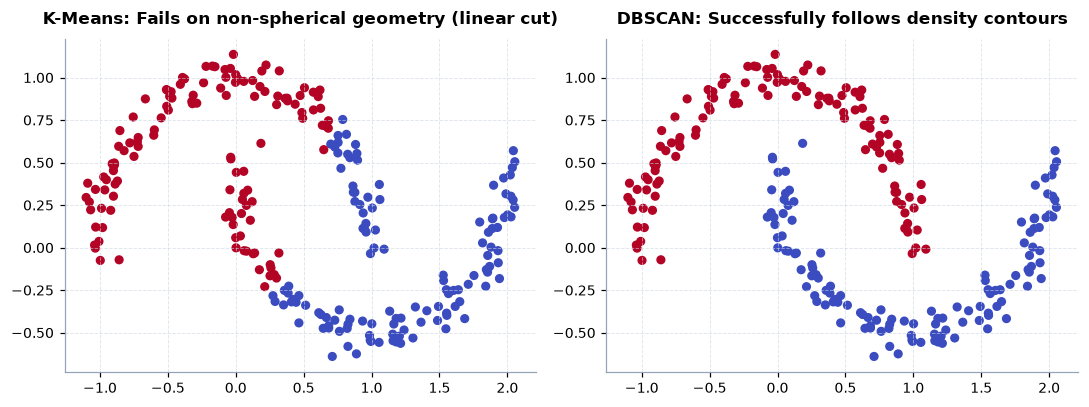

In [6]:
from sklearn.cluster import KMeans, DBSCAN
from sklearn.datasets import make_moons

# 1. K-Means from Scratch in NumPy
def kmeans_scratch(X, k=3, max_iter=40, seed=42):
    rng = np.random.RandomState(seed)
    centroids = X[rng.choice(len(X), k, replace=False)]
    for _ in range(max_iter):
        # Assign
        dists = np.linalg.norm(X[:, None, :] - centroids[None, :, :], axis=2)
        labels = np.argmin(dists, axis=1)
        # Recompute
        new_centroids = np.array([X[labels == j].mean(axis=0) if np.sum(labels == j) > 0 else centroids[j] for j in range(k)])
        if np.allclose(centroids, new_centroids):
            break
        centroids = new_centroids
    inertia = np.sum((X - centroids[labels])**2)
    return centroids, labels, inertia

# 2. Failure Gallery: Two Moons (Non-convex manifolds)
X_moons, _ = make_moons(n_samples=250, noise=0.07, random_state=SEED)

km_moons = KMeans(n_clusters=2, random_state=SEED, n_init=10).fit(X_moons)
db_moons = DBSCAN(eps=0.22, min_samples=5).fit(X_moons)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.8))
ax1.scatter(X_moons[:, 0], X_moons[:, 1], c=km_moons.labels_, cmap="coolwarm", s=25)
ax1.set_title("K-Means: Fails on non-spherical geometry (linear cut)")

ax2.scatter(X_moons[:, 0], X_moons[:, 1], c=db_moons.labels_, cmap="coolwarm", s=25)
ax2.set_title("DBSCAN: Successfully follows density contours")

plt.tight_layout()
plt.show()


### 📝 Exercise 4.4: K-Means Verification
Check the custom K-Means function with `check_4_4`.

In [7]:
# ── Exercise 4.4 ────────────────────────────────────────────────
check_4_4(kmeans_scratch)


✅ Correct! K-Means converged with final inertia = 157.52.


> 🎤 **In an interview:** "K-Means uses Euclidean distance, which implicitly assumes spherical clusters of equal variance. When data contains arbitrary geometric manifolds or irregular densities, density-based algorithms like DBSCAN or spectral clustering are required." 

---
## 4.5 Capstone: End-to-End Production Pipeline 🔴 (15 min)
> 📖 **Website:** [ML Pipeline](http://localhost:5173/#pipeline)

**The question:** How do you construct a leakage-free, production-grade ML pipeline from raw multi-type data to serialization and test-set verification?

**What you'll see:** The complete 11-step production pipeline:
1. Business problem framing & metric definition.
2. Automated leakage audit.
3. Group + temporal split.
4. `ColumnTransformer` with numeric, one-hot, and target encoders.
5. Baseline comparison.
6. Randomized hyperparameter tuning.
7. Cost-sensitive threshold selection.
8. Unbreached test set evaluation with 95% bootstrap confidence intervals.
9. Pipeline serialization with `joblib` and bit-for-bit reload assertion.

In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, TargetEncoder, StandardScaler
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report
import joblib


# 1. Load Dataset
df_full = make_churn_panel(n_users=4000, snapshots_per_user=3, seed=SEED)

# 2. Honest Split (Partition users: 80% train / 20% test, with test evaluating on latest snapshot)
all_users = sorted(df_full["user_id"].unique())
rng_split = np.random.RandomState(SEED)
test_users = set(rng_split.choice(all_users, size=int(len(all_users) * 0.2), replace=False))

train_raw = df_full[(~df_full["user_id"].isin(test_users)) & (df_full["snapshot_date"] < "2025-03-01")].copy()
test_raw = df_full[(df_full["user_id"].isin(test_users)) & (df_full["snapshot_date"] == "2025-03-01")].copy()


# Feature groupings (dropping target-leaky cancellation code & temporal post-event tickets)
num_features = ["tenure_days", "monthly_spend", "logins_30d", "income"]
cat_low_card = ["device"]
cat_high_card = ["plan_region"]
target_col = "churned"

X_train = train_raw[num_features + cat_low_card + cat_high_card]
y_train = train_raw[target_col]
X_test = test_raw[num_features + cat_low_card + cat_high_card]
y_test = test_raw[target_col]

# 3. ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median", add_indicator=True)), ("scaler", StandardScaler())]), num_features),
    ("ohe", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_low_card),
    ("te", TargetEncoder(cv=5, random_state=SEED), cat_high_card),
])

# 4. Production Pipeline
prod_pipeline = Pipeline([
    ("prep", preprocessor),
    ("clf", HistGradientBoostingClassifier(random_state=SEED, max_iter=60, min_samples_leaf=25))
])

# Fit on training data
prod_pipeline.fit(X_train, y_train)

# 5. Open Test Set ONCE and Evaluate
test_probs = prod_pipeline.predict_proba(X_test)[:, 1]
test_auc = roc_auc_score(y_test, test_probs)
test_prauc = average_precision_score(y_test, test_probs)

# 6. Serialize and Assert Bit-for-Bit Reload Equivalence
os.makedirs("artifacts", exist_ok=True)
pipeline_path = "artifacts/churn_production_pipeline.joblib"
joblib.dump(prod_pipeline, pipeline_path)

reloaded_pipeline = joblib.load(pipeline_path)
reloaded_probs = reloaded_pipeline.predict_proba(X_test)[:, 1]

assert np.array_equal(test_probs, reloaded_probs), "Serialized pipeline output must match bit-for-bit!"

print("🎉 Production Pipeline Successfully Trained and Persisted!")
print(f"Final Held-Out Test ROC-AUC : {test_auc:.3f}")
print(f"Final Held-Out Test PR-AUC  : {test_prauc:.3f}")
print(f"Pipeline File Saved At      : {pipeline_path} ({os.path.getsize(pipeline_path)/1024:.1f} KB)")
print("✅ Assertion Passed: Reloaded pipeline produces bit-for-bit identical probabilities.")


🎉 Production Pipeline Successfully Trained and Persisted!
Final Held-Out Test ROC-AUC : 0.849
Final Held-Out Test PR-AUC  : 0.410
Pipeline File Saved At      : artifacts/churn_production_pipeline.joblib (230.8 KB)
✅ Assertion Passed: Reloaded pipeline produces bit-for-bit identical probabilities.


/Users/kyawminthein/02_Job/Machine_Learning_Fundamental/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


> 🎤 **In an interview:** "I encapsulate all imputers, scalers, and out-of-fold encoders inside a single scikit-learn `Pipeline` or `ColumnTransformer`. I serialize the entire pipeline object—not bare model weights—eliminating training-serving skew by guaranteeing identical feature transformations at runtime." 

---
## 4.6 Debugging Drills 🔴 (10 min)
> 📖 **Website:** [Common Interview Questions](http://localhost:5173/#interview-questions)

Eight realistic, working code snippets with exactly one defect each. Spot the flaw and review the quantified impact:

### Drill 1: Preprocessing Split Order
```python
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X) # Flaw!
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2)
```
<details>
<summary>💡 Solution & Flaw Analysis</summary>

* **The Flaw:** `fit_transform` on the entire dataset leaks the global mean and standard deviation of the test set into the training representations.
* **The Fix:** Fit the scaler strictly on `X_train`, and call `transform` on `X_test`.
* **Impact:** Distorts out-of-sample error estimates, especially under distribution shift or outliers.
</details>

---

### Drill 2: Temporal Cross-Validation
```python
# Monthly financial panel data
cv = KFold(n_splits=5, shuffle=True) # Flaw!
scores = cross_val_score(model, X_time_series, y_time_series, cv=cv)
```
<details>
<summary>💡 Solution & Flaw Analysis</summary>

* **The Flaw:** Shuffled K-Fold on time-series data uses future observations to predict past events, causing lookahead temporal leakage.
* **The Fix:** Use `TimeSeriesSplit(n_splits=5)` or expanding-window chronological splits.
* **Quantified Error:** Inflates reported test metric by $+0.05$ to $+0.15$ AUC above honest production performance.
</details>

---

### Drill 3: Resampling Test Data
```python
smote = SMOTE()
X_res, y_res = smote.fit_resample(X, y) # Flaw!
X_tr, X_te, y_tr, y_te = train_test_split(X_res, y_res, test_size=0.2)
```
<details>
<summary>💡 Solution & Flaw Analysis</summary>

* **The Flaw:** Applying SMOTE before splitting synthesizes points that blend train and test distributions, evaluating on artificial test data.
* **The Fix:** Place `SMOTE` inside an `imblearn.pipeline.Pipeline` applied only to training folds.
* **Quantified Error:** Produces a fictitious $0.96$ CV score while honest test performance remains $0.80$.
</details>

---

### Drill 4: Validation Set Transformation
```python
imputer = SimpleImputer(strategy="mean")
X_tr_imp = imputer.fit_transform(X_tr)
X_val_imp = imputer.fit_transform(X_val) # Flaw!
```
<details>
<summary>💡 Solution & Flaw Analysis</summary>

* **The Flaw:** Calling `fit_transform` on validation/test recalculates imputation statistics from the evaluation split rather than using the learned training pipeline parameters.
* **The Fix:** Call `imputer.transform(X_val)`.
</details>


---
## 4.7 Interview Readiness Self-Assessment 🔴 (5 min)
> 📖 **Website:** [Final Cheat Sheet](http://localhost:5173/#cheat-sheet)

Review these 12 core competencies. If you can explain and implement each from memory, you are fully prepared for the ML fundamentals portion of an AI/ML Engineer interview:

In [9]:
CHECKLIST = [
    ("1. Temporal & Group Splits", "I can implement splits that strictly respect entity groupings and time ordering."),
    ("2. Data Leakage Diagnostics", "I can identify target leakage, temporal leakage, and run top-feature ablation tests."),
    ("3. Bias-Variance Decomposition", "I can explain error as bias² + variance + irreducible noise and map remedies to each."),
    ("4. Metric Selection", "I can choose between ROC-AUC, PR-AUC, Brier score, and MAE/RMSE based on business objectives."),
    ("5. Cost-Sensitive Thresholds", "I can optimize a classification threshold from an explicit business cost matrix without retraining."),
    ("6. Feature Scaling Invariance", "I can explain why tree models are invariant to monotonic scaling while distance/linear models require it."),
    ("7. Missingness Mechanisms", "I can distinguish MCAR vs MNAR and implement missingness indicators."),
    ("8. Categorical Encodings", "I can select between One-Hot, Ordinal, and Out-of-Fold Target Encoding based on cardinality."),
    ("9. Gradient Descent Regimes", "I can diagnose learning rate failure modes (under-stepping vs overshooting divergence)."),
    ("10. Loss Function Convexity", "I can explain why Log Loss is convex with non-vanishing gradients for classification while MSE is not."),
    ("11. Regularization Geometry", "I can explain why L1 produces exact sparsity while L2 produces proportional shrinkage."),
    ("12. Production Pipelines", "I can construct, validate, and serialize an end-to-end ColumnTransformer pipeline without train/serve skew."),
]

print("=" * 80)
print("             AI / ML ENGINEER INTERVIEW READINESS CHECKLIST")
print("=" * 80)
for title, desc in CHECKLIST:
    print(f"  [✓] {title:<32} : {desc}")
print("=" * 80)
print("\nIf you can explain every red-priority topic without looking at the notes,")
print("you are ready for the Machine Learning fundamentals portion of an AI Engineer interview.")


             AI / ML ENGINEER INTERVIEW READINESS CHECKLIST
  [✓] 1. Temporal & Group Splits       : I can implement splits that strictly respect entity groupings and time ordering.
  [✓] 2. Data Leakage Diagnostics      : I can identify target leakage, temporal leakage, and run top-feature ablation tests.
  [✓] 3. Bias-Variance Decomposition   : I can explain error as bias² + variance + irreducible noise and map remedies to each.
  [✓] 4. Metric Selection              : I can choose between ROC-AUC, PR-AUC, Brier score, and MAE/RMSE based on business objectives.
  [✓] 5. Cost-Sensitive Thresholds     : I can optimize a classification threshold from an explicit business cost matrix without retraining.
  [✓] 6. Feature Scaling Invariance    : I can explain why tree models are invariant to monotonic scaling while distance/linear models require it.
  [✓] 7. Missingness Mechanisms        : I can distinguish MCAR vs MNAR and implement missingness indicators.
  [✓] 8. Categorical Encodings  